In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('Listings_50_Limpio.csv')

In [4]:
df.head()

,id,name,description,neighborhood_overview,instant_bookable,host_id,host_name,host_since,host_location,host_about,...,number_of_reviews_ltm,reviews_per_month,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_value
0,97945,Deluxw-Apartm. with roof terrace,Sin información,Sin información,Sin información,517685,Angelika,Sin información,"Munich, Germany",Ich freue mich auf viele internationale Gäste!...,...,0,0.70,2011-10-03,2019-10-03,4.84,4.89,4.81,4.90,4.93,4.73
1,114695,Apartment Munich/East with sundeck,Sin información,Sin información,Sin información,581737,Stephan,Sin información,"Munich, Germany",I am looking forward to meet interesting peopl...,...,4,0.46,2011-07-08,2025-10-01,4.83,4.77,4.94,4.98,5.00,4.62
2,127383,City apartment next to Pinakothek,Sin información,Sin información,Sin información,630556,Sonja,Sin información,"Munich, Germany","Hi, mein Name ist Sonja und ich freue mich net...",...,7,0.68,2011-06-04,2026-05-17,4.84,4.91,4.80,4.98,4.96,4.80
3,159634,"Fancy, bright central roof top flat in quiet area",In this idyllic stylish flat you live very qui...,Sin información,Sin información,765694,Susanna,Sin información,"Munich, Germany",outdoorsy sportive Person from Munich. I love ...,...,7,0.29,2011-08-15,2026-06-13,4.62,4.71,4.31,4.71,4.83,4.46
4,170154,"Own floor & bath, parking & breakfast","Enjoy a quiet neighbourhood, easy access to th...",Sin información,Sin información,108297,Alexander,Sin información,"Munich, Germany",We love to travel and dream of living in a hou...,...,17,3.35,2011-09-25,2026-06-27,4.96,4.96,4.99,4.99,4.98,4.91


In [5]:
df.columns

Index(['id', 'name', 'description', 'neighborhood_overview',
       'instant_bookable', 'host_id', 'host_name', 'host_since',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_listings_count', 'host_identity_verified',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'license', 'price',
       'minimum_nights', 'maximum_nights', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'price_quote_price_per_night',
       'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month',
       'first_review', 'last_review', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_sc

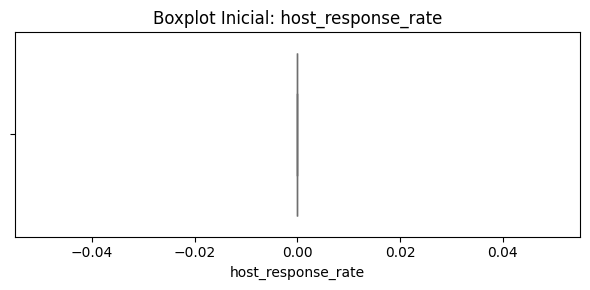

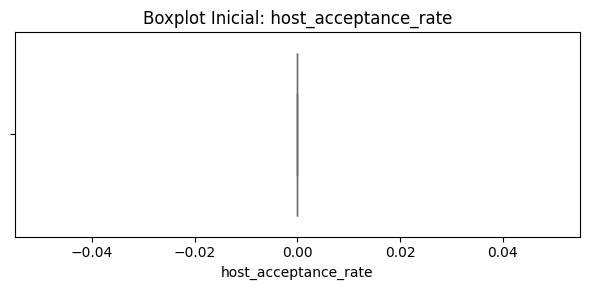

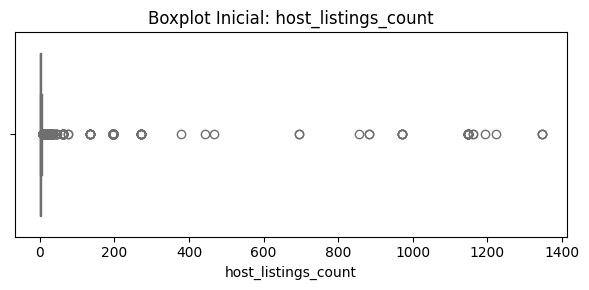

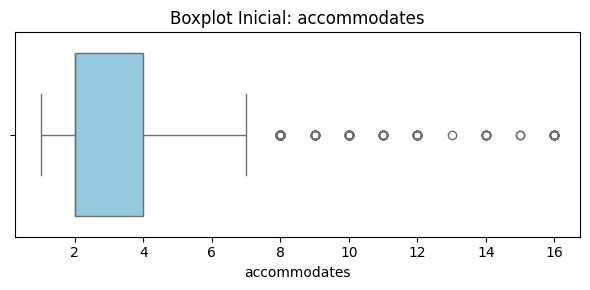

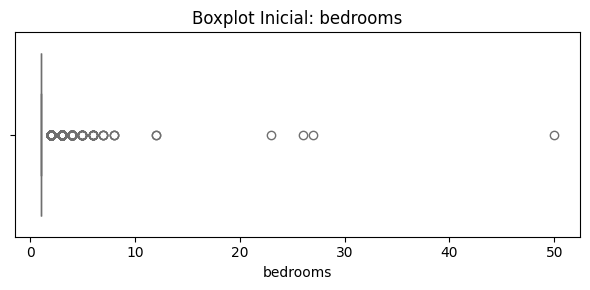

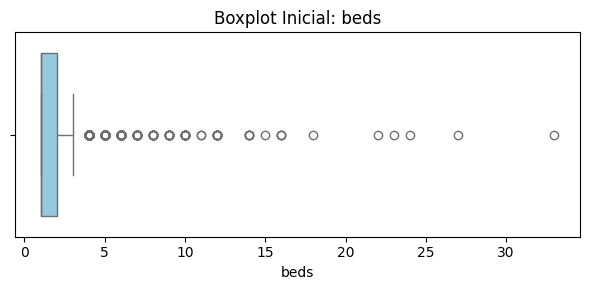

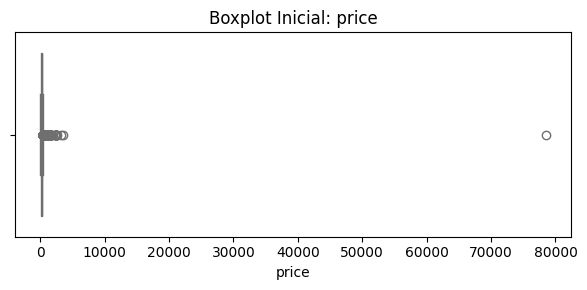

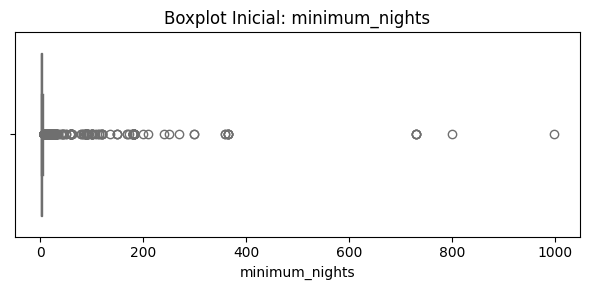

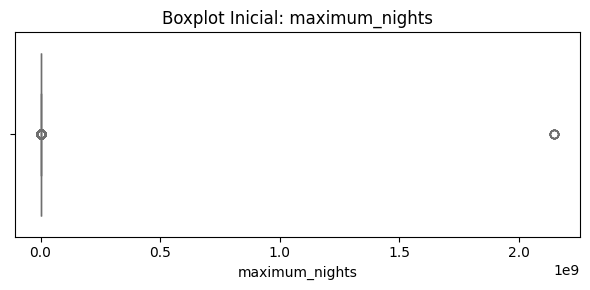

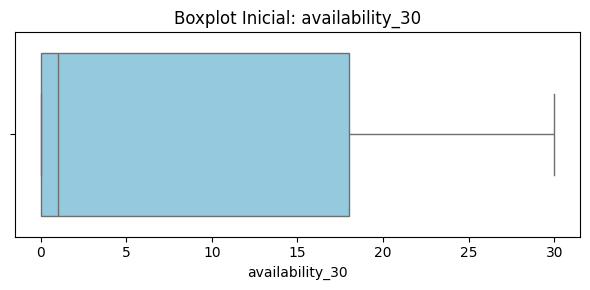

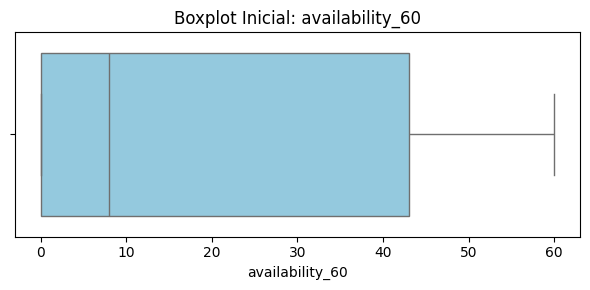

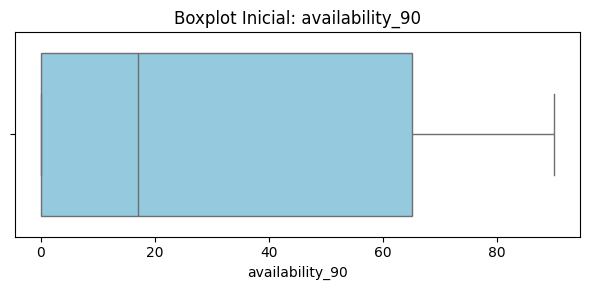

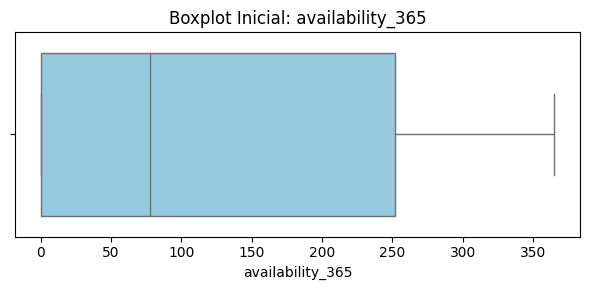

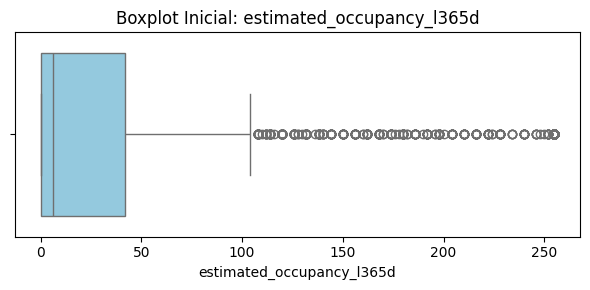

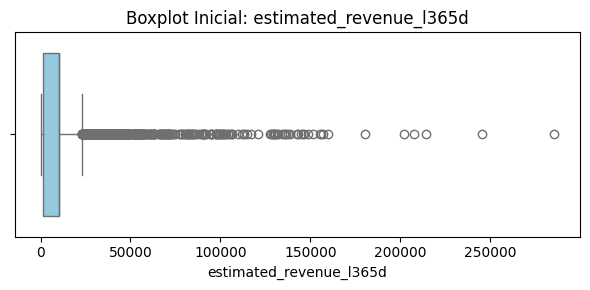

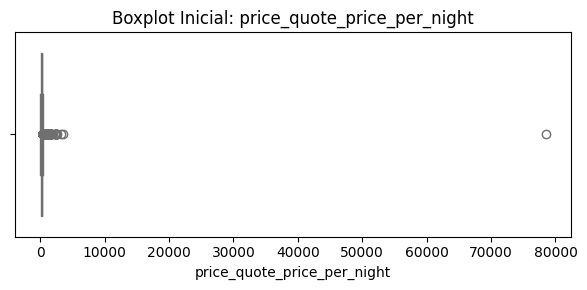

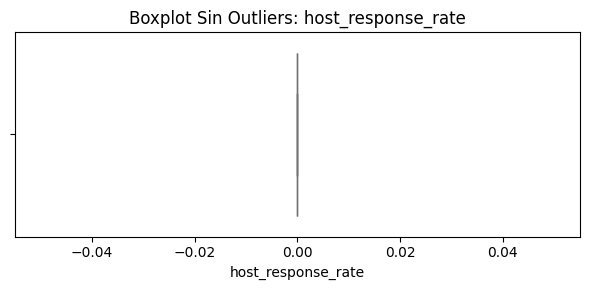

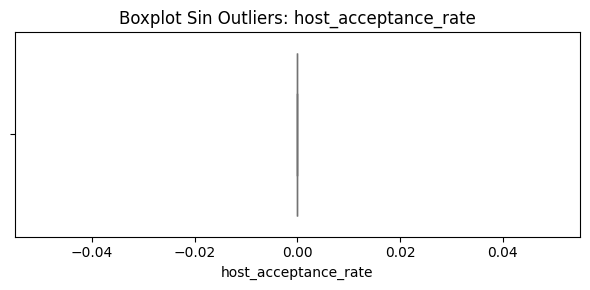

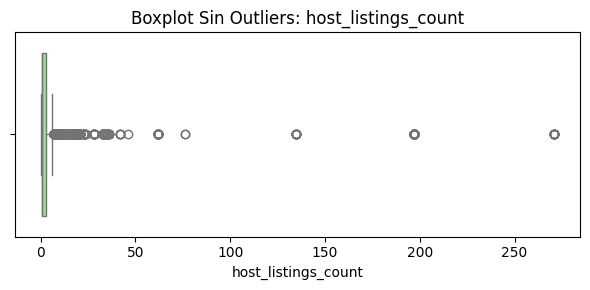

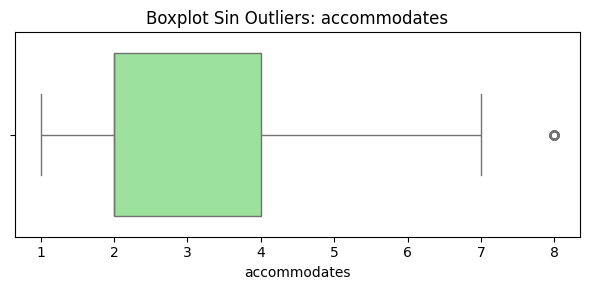

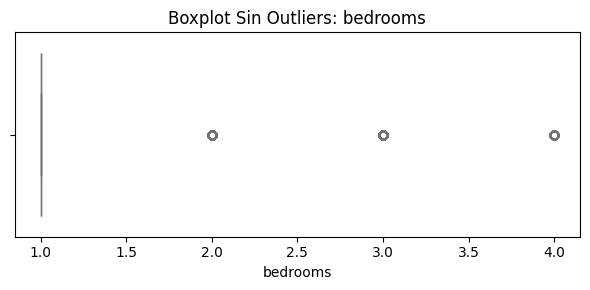

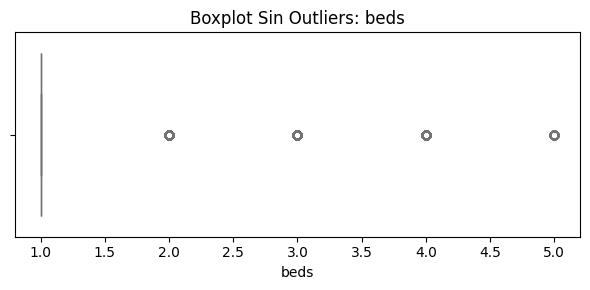

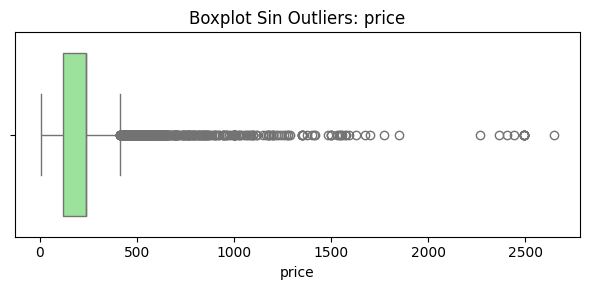

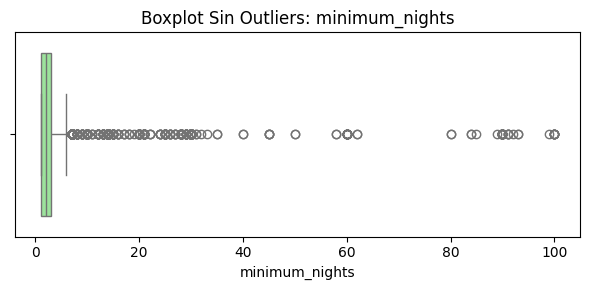

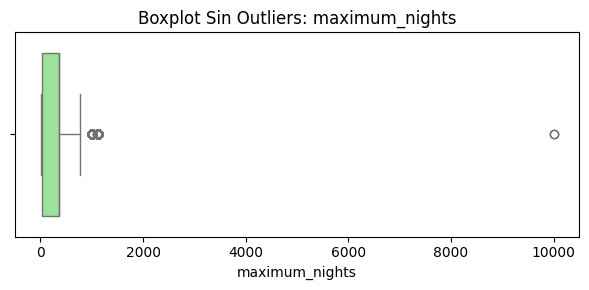

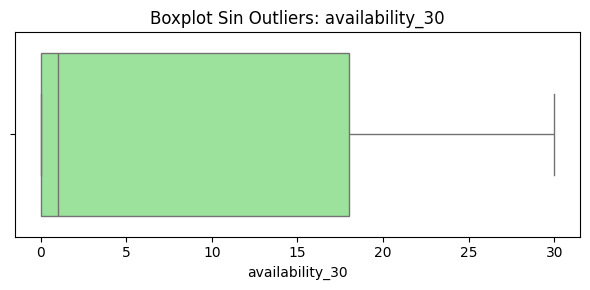

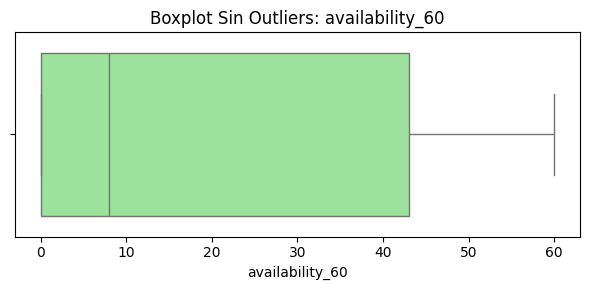

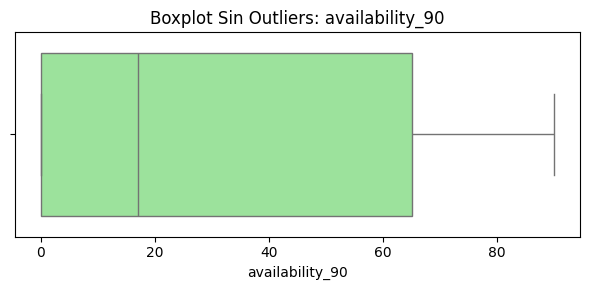

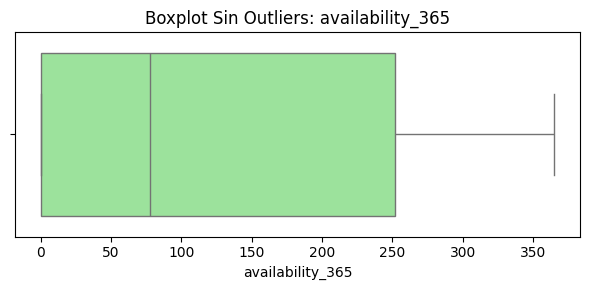

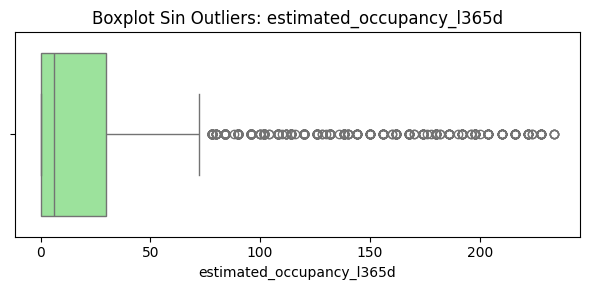

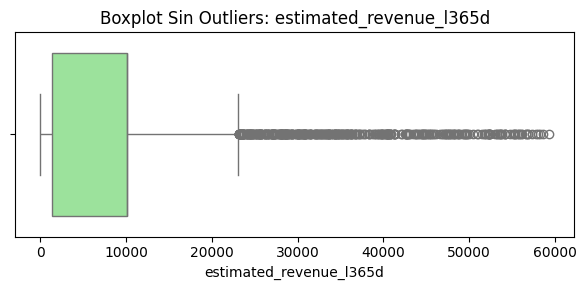

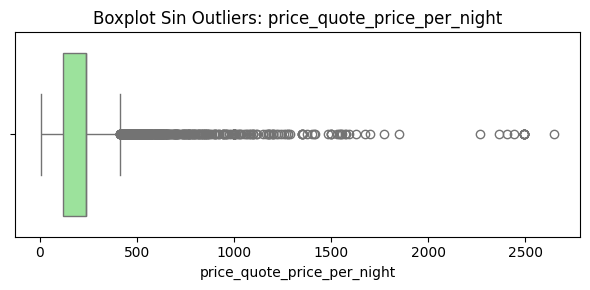

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("Listings_50_Limpio.csv")

cols_excluir = [
    "latitude",
    "longitude",
    "id",
    "host_id",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_value",
]

num_cols_todas = df.select_dtypes(include=[np.number]).columns
cols_a_tratar = [col for col in num_cols_todas if col not in cols_excluir]

for col in cols_a_tratar:
  plt.figure(figsize=(6, 3))
  sns.boxplot(x=df[col], color="skyblue")
  plt.title(f"Boxplot Inicial: {col}")
  plt.tight_layout()
  plt.show()

df_sin_outliers = df.copy()

for col in cols_a_tratar:
  media = df_sin_outliers[col].mean()
  std = df_sin_outliers[col].std()
  mediana = df_sin_outliers[col].median()

  limite_inferior = media - 3 * std
  limite_superior = media + 3 * std

  outliers = (df_sin_outliers[col] < limite_inferior) | (
      df_sin_outliers[col] > limite_superior
  )
  df_sin_outliers.loc[outliers, col] = mediana

for col in cols_a_tratar:
  plt.figure(figsize=(6, 3))
  sns.boxplot(x=df_sin_outliers[col], color="lightgreen")
  plt.title(f"Boxplot Sin Outliers: {col}")
  plt.tight_layout()
  plt.show()

df_sin_outliers.to_csv("munich_limpio.csv", index=False)